In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import random
from transformers import pipeline

from src.similarity_models import (
    jaccard_similarity,
    tfidf_similarity,
    embedding_similarity
)

2026-03-09 22:07:40.028160: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/nyct_cg/ml_env/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
df = pd.read_csv("../data/processed/abstracts_clean.csv")

print(df.shape)
df.head()

(10000, 2)


,id,abstract
0,704.0001,A fully differential calculation in perturba...
1,704.0002,"We describe a new algorithm, the $(k,\ell)$-..."
2,704.0003,The evolution of Earth-Moon system is descri...
3,704.0006,We study the two-particle wave function of p...
4,704.0007,A rather non-standard quantum representation...


In [3]:
paraphraser = pipeline(
    "text2text-generation",
    model="Vamsi/T5_Paraphrase_Paws",
    tokenizer="Vamsi/T5_Paraphrase_Paws"
)

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Device set to use cpu


In [4]:
def generate_paraphrase(text):

    prompt = "paraphrase: " + text

    output = paraphraser(
        prompt,
        max_length=256,
        do_sample=True,
        top_k=50,
        top_p=0.95
    )

    return output[0]["generated_text"]

In [5]:
original = df.loc[0, "abstract"]

paraphrased = generate_paraphrase(original)

print("ORIGINAL:\n")
print(original[:500])

print("\nPARAPHRASED:\n")
print(paraphrased[:500])

Both `max_new_tokens` (=256) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ORIGINAL:

  A fully differential calculation in perturbative quantum chromodynamics is
presented for the production of massive photon pairs at hadron colliders. All
next-to-leading order perturbative contributions from quark-antiquark,
gluon-(anti)quark, and gluon-gluon subprocesses are included, as well as
all-orders resummation of initial-state gluon radiation valid at
next-to-next-to-leading logarithmic accuracy. The region of phase space is
specified in which the calculation is most reliable. Good agr

PARAPHRASED:

A fully differential calculation in perturbative quantum chromodynamics is presented for the production of massive photon pairs at Hadron colliders . All next-to-leading order perturbative contributions from quark-antiquark, gluon-(anti)quark and gluon-gluon subprocesses are included , as well as all-order resummation of initial-state gluon radiation valid at next-to-leading logarithmic accuracy . Good agreement is demonstrated


In [6]:
print("Jaccard:", jaccard_similarity(original, paraphrased))
print("TF-IDF:", tfidf_similarity(original, paraphrased))
print("Embedding:", embedding_similarity(original, paraphrased))

Jaccard: 0.34210526315789475
TF-IDF: 0.6497706882862969
Embedding: 0.825915


In [7]:
sample_indices = random.sample(list(df.index), 30)

results = []

In [8]:
for idx in sample_indices:

    original = df.loc[idx, "abstract"]

    try:
        paraphrased = generate_paraphrase(original)

        results.append({
            "jaccard": jaccard_similarity(original, paraphrased),
            "tfidf": tfidf_similarity(original, paraphrased),
            "embedding": embedding_similarity(original, paraphrased)
        })

    except:
        continue

Both `max_new_tokens` (=256) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [9]:
results_df = pd.DataFrame(results)

results_df.head()

,jaccard,tfidf,embedding
0,0.313609,0.743812,0.906070
1,0.362069,0.837639,0.832118
2,0.411392,0.849922,0.887843
3,0.652174,0.959269,0.960689
4,0.647059,0.920079,0.916674


In [10]:
summary = results_df.mean()

print(summary)

jaccard      0.500083
tfidf        0.846789
embedding    0.925465
dtype: float64


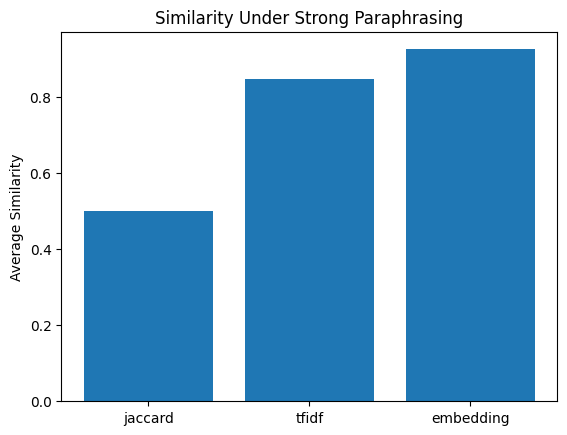

In [11]:
import matplotlib.pyplot as plt

metrics = ["jaccard", "tfidf", "embedding"]

values = [summary[m] for m in metrics]

plt.bar(metrics, values)

plt.title("Similarity Under Strong Paraphrasing")
plt.ylabel("Average Similarity")

plt.show()